# Multi-Scale Bayesian Optimization Results Analysis

This notebook analyzes the results from hyperparameter sweep experiments comparing:
- **Black-box NLP**: Multi-start gradient-based optimization
- **Black-box BO**: Bayesian Optimization over all variables
- **Bi-level BO**: BO over material variables + NLP for process variables

We examine the effect of:
- `n_init`: Number of initial samples (1, 5, 20, 50)
- `xi`: Exploration-exploitation trade-off parameter (0.001 to 1.0)

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12

## 1. Load All Results

In [2]:
# Find all result files
results_dir = Path('results')
result_files = list(results_dir.glob('results_all_ei_ninit*.pkl'))

print(f"Found {len(result_files)} result files:")
for f in sorted(result_files):
    print(f"  - {f.name}")

Found 18 result files:
  - results_all_ei_ninit1_xi0.001.pkl
  - results_all_ei_ninit1_xi0.01.pkl
  - results_all_ei_ninit1_xi0.05.pkl
  - results_all_ei_ninit1_xi0.1.pkl
  - results_all_ei_ninit1_xi0.2.pkl
  - results_all_ei_ninit1_xi0.5.pkl
  - results_all_ei_ninit1_xi1.0.pkl
  - results_all_ei_ninit20_xi0.001.pkl
  - results_all_ei_ninit20_xi0.01.pkl
  - results_all_ei_ninit20_xi0.05.pkl
  - results_all_ei_ninit20_xi0.1.pkl
  - results_all_ei_ninit5_xi0.001.pkl
  - results_all_ei_ninit5_xi0.01.pkl
  - results_all_ei_ninit5_xi0.05.pkl
  - results_all_ei_ninit5_xi0.1.pkl
  - results_all_ei_ninit5_xi0.2.pkl
  - results_all_ei_ninit5_xi0.5.pkl
  - results_all_ei_ninit5_xi1.0.pkl


In [3]:
def load_results(filepath):
    """Load results from a pickle file."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return data['settings'], data['results']

def parse_filename(filename):
    """Extract n_init and xi from filename."""
    name = filename.stem
    parts = name.split('_')
    n_init = None
    xi = None
    for part in parts:
        if part.startswith('ninit'):
            n_init = int(part[5:])
        elif part.startswith('xi'):
            xi = float(part[2:])
    return n_init, xi

# Load all results into a dictionary
all_data = {}
for filepath in sorted(result_files):
    n_init, xi = parse_filename(filepath)
    if n_init is not None and xi is not None:
        settings, results = load_results(filepath)
        all_data[(n_init, xi)] = {
            'settings': settings,
            'results': results
        }
        print(f"Loaded n_init={n_init}, xi={xi}: {len(results)} problems")

print(f"\nTotal configurations loaded: {len(all_data)}")

Loaded n_init=1, xi=0.001: 13 problems
Loaded n_init=1, xi=0.01: 13 problems
Loaded n_init=1, xi=0.05: 13 problems
Loaded n_init=1, xi=0.1: 13 problems
Loaded n_init=1, xi=0.2: 13 problems
Loaded n_init=1, xi=0.5: 13 problems
Loaded n_init=1, xi=1.0: 13 problems
Loaded n_init=20, xi=0.001: 13 problems
Loaded n_init=20, xi=0.01: 13 problems
Loaded n_init=20, xi=0.05: 13 problems
Loaded n_init=20, xi=0.1: 13 problems
Loaded n_init=5, xi=0.001: 13 problems
Loaded n_init=5, xi=0.01: 13 problems
Loaded n_init=5, xi=0.05: 13 problems
Loaded n_init=5, xi=0.1: 13 problems
Loaded n_init=5, xi=0.2: 13 problems
Loaded n_init=5, xi=0.5: 13 problems
Loaded n_init=5, xi=1.0: 13 problems

Total configurations loaded: 18


In [4]:
# Extract unique parameter values
n_init_values = sorted(set(k[0] for k in all_data.keys()))
xi_values = sorted(set(k[1] for k in all_data.keys()))

print(f"n_init values: {n_init_values}")
print(f"xi values: {xi_values}")

# Get problem names from first result
sample_key = list(all_data.keys())[0]
problem_names = list(all_data[sample_key]['results'].keys())
print(f"\nProblems: {problem_names}")

n_init values: [1, 5, 20]
xi values: [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

Problems: ['Small-Feasible-Region', 'Small-Feasible-Region-2', 'Rastrigin', 'Toy-Hydrology', 'Rosen-Suzuki', 'CSTR', 'Heat-Exchanger', 'PSA', 'Batch-Reactor', 'Distillation', 'Evaporator', 'Membrane', 'Williams-Otto']


## 2. Build Summary DataFrames

In [5]:
def extract_metrics(data_dict):
    """Extract key metrics from all experiments into DataFrames."""
    rows = []
    
    for (n_init, xi), data in data_dict.items():
        results = data['results']
        settings = data['settings']
        n_reps = settings['n_repetitions']
        
        for prob_name, prob_results in results.items():
            # Black-box NLP metrics
            nlp_data = prob_results['blackbox_nlp']
            for rep_idx in range(len(nlp_data['final_regrets'])):
                rows.append({
                    'n_init': n_init,
                    'xi': xi,
                    'problem': prob_name,
                    'method': 'NLP',
                    'rep': rep_idx,
                    'final_regret': nlp_data['final_regrets'][rep_idx],
                    'n_bb_evals': nlp_data['n_fbb_evals'][rep_idx],
                    'wall_time': nlp_data['wall_times'][rep_idx],
                    'best_J': nlp_data['best_Js'][rep_idx]
                })
            
            # BO methods
            for acq in prob_results.get('acquisitions', ['ei']):
                # Black-box BO
                bb_key = f'blackbox_bo_{acq}'
                if bb_key in prob_results:
                    bb_data = prob_results[bb_key]
                    for rep_idx in range(len(bb_data['regrets'])):
                        regret_curve = bb_data['regrets'][rep_idx]
                        final_regret = regret_curve[-1] if len(regret_curve) > 0 else np.inf
                        rows.append({
                            'n_init': n_init,
                            'xi': xi,
                            'problem': prob_name,
                            'method': f'BB-BO ({acq.upper()})',
                            'rep': rep_idx,
                            'final_regret': final_regret,
                            'n_bb_evals': bb_data['n_fbb_evals'][rep_idx],
                            'wall_time': bb_data['wall_times'][rep_idx],
                            'best_J': bb_data['best_Js'][rep_idx]
                        })
                
                # Bi-level BO
                bi_key = f'bilevel_bo_{acq}'
                if bi_key in prob_results:
                    bi_data = prob_results[bi_key]
                    for rep_idx in range(len(bi_data['regrets'])):
                        regret_curve = bi_data['regrets'][rep_idx]
                        final_regret = regret_curve[-1] if len(regret_curve) > 0 else np.inf
                        rows.append({
                            'n_init': n_init,
                            'xi': xi,
                            'problem': prob_name,
                            'method': f'Bi-BO ({acq.upper()})',
                            'rep': rep_idx,
                            'final_regret': final_regret,
                            'n_bb_evals': bi_data['n_fbb_evals'][rep_idx],
                            'wall_time': bi_data['wall_times'][rep_idx],
                            'best_J': bi_data['best_Js'][rep_idx]
                        })
    
    return pd.DataFrame(rows)

df = extract_metrics(all_data)
print(f"Total rows: {len(df)}")
df.head()

Total rows: 7020


,n_init,xi,problem,method,rep,final_regret,n_bb_evals,wall_time,best_J
0,1,0.001,Small-Feasible-Region,NLP,0,-5.208359e-07,853,0.031587,2.532355e-01
1,1,0.001,Small-Feasible-Region,NLP,1,-2.808620e-06,859,0.027769,2.532332e-01
2,1,0.001,Small-Feasible-Region,NLP,2,-2.532360e-01,1177,0.032723,4.464295e-13
3,1,0.001,Small-Feasible-Region,NLP,3,-2.532360e-01,1052,0.028020,3.366706e-13
4,1,0.001,Small-Feasible-Region,NLP,4,-2.532360e-01,1005,0.026332,0.000000e+00


In [6]:
# Filter out infinite regret values for cleaner analysis
df_valid = df[~np.isinf(df['final_regret'])].copy()
print(f"Valid rows (non-inf regret): {len(df_valid)} / {len(df)}")

# Summary statistics
df_valid.groupby(['method', 'problem']).agg({
    'final_regret': ['mean', 'std', 'min'],
    'wall_time': ['mean', 'std'],
    'n_bb_evals': ['mean', 'std']
}).round(4)

Valid rows (non-inf regret): 6992 / 7020


final_regret                        \
                                           mean        std        min   
method     problem                                                      
BB-BO (EI) Batch-Reactor                 1.4848     0.9487     0.2443   
           CSTR                          3.1831     1.5025     0.6121   
           Distillation               6069.5060  2573.2053  1364.3908   
           Evaporator                    0.5527     0.3251     0.2543   
           Heat-Exchanger               68.9694    55.7136     4.4463   
           Membrane                     21.5871    14.2652     3.4497   
           PSA                           0.4412     0.1452     0.1046   
           Rastrigin                     7.8591     3.3426     0.7985   
           Rosen-Suzuki                  7.4878     2.7665     1.3466   
           Small-Feasible-Region         2.7087     2.5128     0.0031   
           Small-Feasible-Region-2       0.2266     0.1687     0.0016   
           Toy-Hydrology                 0.0923     0.0609     0.0049   
           Williams-Otto                 2.5262     1.3840     0.5095   
Bi-BO (EI) Batch-Reactor                 0.0425     0.0377     0.0016   
           CSTR                          0.0093     0.0136     0.0004   
           Distillation                 -0.8156     0.0399    -0.8479   
           Evaporator                    0.0584     0.0699     0.0014   
           Heat-Exchanger                0.0002     0.0000     0.0002   
           Membrane                     -0.0002     0.0002    -0.0004   
           PSA                           0.0103     0.0169     0.0001   
           Rastrigin                     0.0014     0.0069     0.0000   
           Rosen-Suzuki                  0.8216     1.3715     0.0030   
           Small-Feasible-Region         0.0569     0.0505     0.0028   
           Small-Feasible-Region-2       0.0006     0.0027     0.0000   
           Toy-Hydrology                 0.0002     0.0004    -0.0000   
           Williams-Otto                -0.0080     0.0036    -0.0098   
NLP        Batch-Reactor                -0.0003     0.0000    -0.0003   
           CSTR                         -0.0000     0.0000    -0.0000   
           Distillation                 -1.6711     1.6572    -6.4908   
           Evaporator                    0.0000     0.0000     0.0000   
           Heat-Exchanger                0.0002     0.0000     0.0002   
           Membrane                     -0.0004     0.0000    -0.0004   
           PSA                           0.0000     0.0000     0.0000   
           Rastrigin                     3.3829     1.7396     0.9950   
           Rosen-Suzuki                 -0.0000     0.0000    -0.0000   
           Small-Feasible-Region        -0.2026     0.1016    -0.2532   
           Small-Feasible-Region-2       0.0546     0.0671     0.0000   
           Toy-Hydrology                -0.0000     0.0000    -0.0000   
           Williams-Otto                -0.0098     0.0000    -0.0098   

                                   wall_time         n_bb_evals            
                                        mean     std       mean       std  
method     problem                                                         
BB-BO (EI) Batch-Reactor             28.6485  4.9202   207.1871    7.4064  
           CSTR                      30.7327  3.3958   206.7778    7.3047  
           Distillation              29.1815  3.2484   206.7778    7.3047  
           Evaporator                27.1862  3.1582   206.7778    7.3047  
           Heat-Exchanger            29.2107  3.0047   206.7778    7.3047  
           Membrane                  32.4228  6.3002   206.7778    7.3047  
           PSA                       29.1125  2.6573   206.7778    7.3047  
           Rastrigin                 19.9735  1.8310   206.7778    7.3047  
           Rosen-Suzuki              24.3814  2.8117   206.7778    7.3047  
           Small-Feasible-Region     22.8832  2.4007   2

## 3. Effect of n_init on Final Regret

IndexError: index 4 is out of bounds for axis 0 with size 4

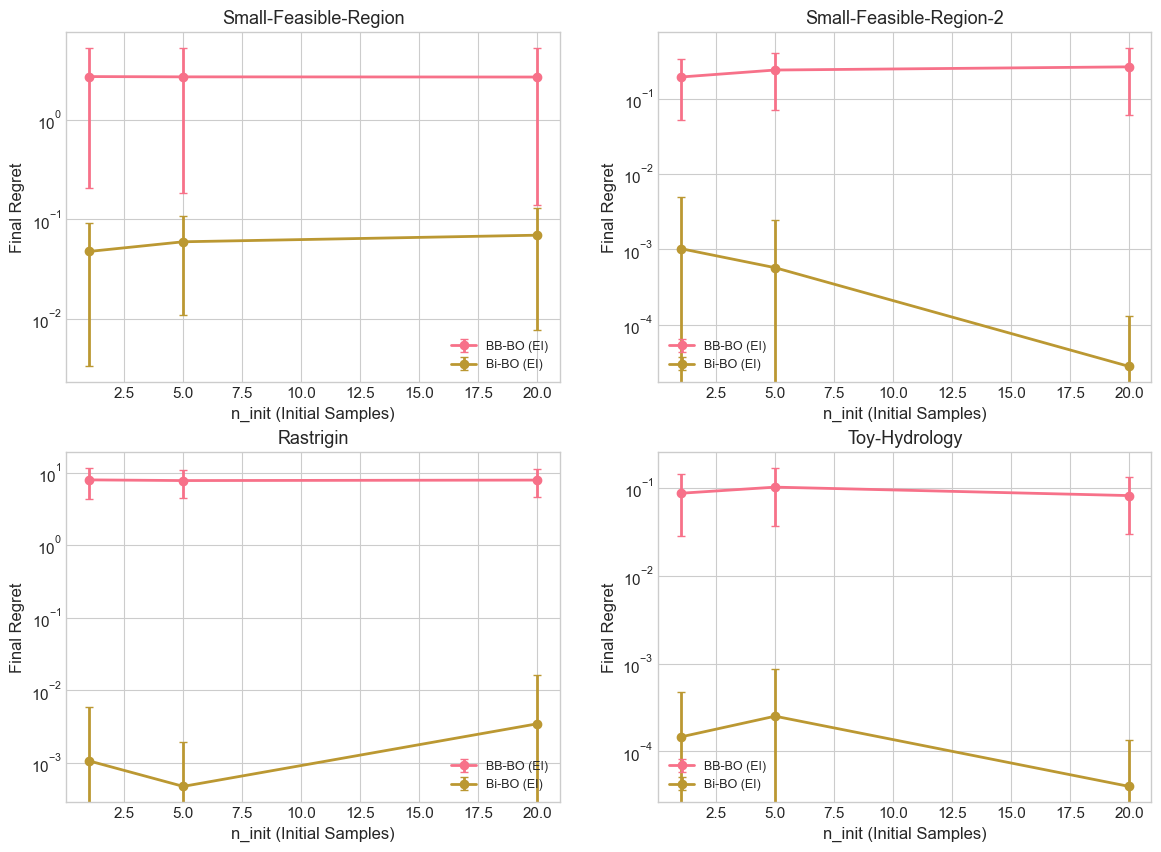

In [7]:
# Filter for BO methods only (NLP doesn't use n_init)
df_bo = df_valid[df_valid['method'] != 'NLP'].copy()

# Aggregate by n_init, method, problem
df_ninit_agg = df_bo.groupby(['n_init', 'method', 'problem']).agg({
    'final_regret': ['mean', 'std', 'count']
}).reset_index()
df_ninit_agg.columns = ['n_init', 'method', 'problem', 'mean_regret', 'std_regret', 'count']

# Plot for each problem
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    df_prob = df_ninit_agg[df_ninit_agg['problem'] == prob]
    
    for method in df_prob['method'].unique():
        df_m = df_prob[df_prob['method'] == method].sort_values('n_init')
        ax.errorbar(df_m['n_init'], df_m['mean_regret'], yerr=df_m['std_regret'],
                   marker='o', label=method, capsize=3, linewidth=2)
    
    ax.set_xlabel('n_init (Initial Samples)')
    ax.set_ylabel('Final Regret')
    ax.set_title(f'{prob}')
    ax.legend(loc='best', fontsize=9)
    ax.set_yscale('log')

plt.suptitle('Effect of n_init on Final Regret (averaged over xi and reps)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/ninit_effect_regret.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Effect of xi on Final Regret

IndexError: index 4 is out of bounds for axis 0 with size 4

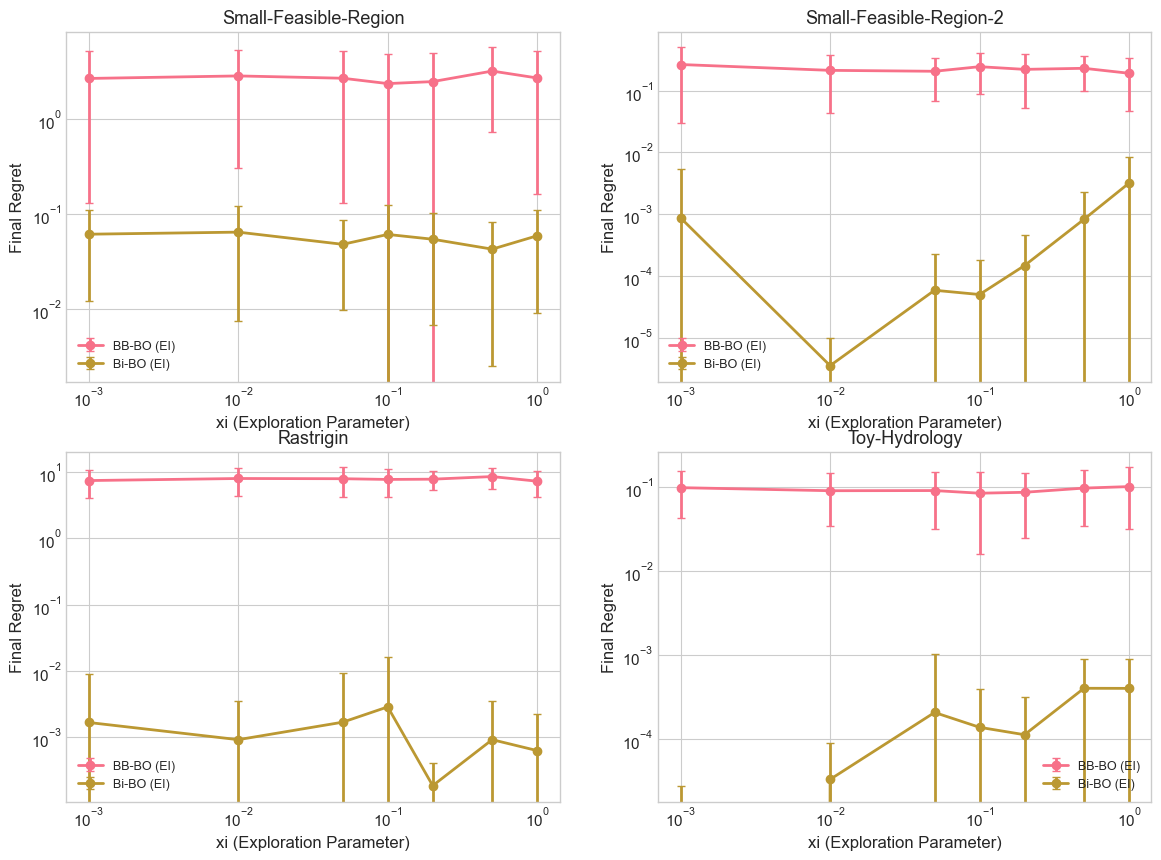

In [8]:
# Aggregate by xi, method, problem
df_xi_agg = df_bo.groupby(['xi', 'method', 'problem']).agg({
    'final_regret': ['mean', 'std', 'count']
}).reset_index()
df_xi_agg.columns = ['xi', 'method', 'problem', 'mean_regret', 'std_regret', 'count']

# Plot for each problem
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    df_prob = df_xi_agg[df_xi_agg['problem'] == prob]
    
    for method in df_prob['method'].unique():
        df_m = df_prob[df_prob['method'] == method].sort_values('xi')
        ax.errorbar(df_m['xi'], df_m['mean_regret'], yerr=df_m['std_regret'],
                   marker='o', label=method, capsize=3, linewidth=2)
    
    ax.set_xlabel('xi (Exploration Parameter)')
    ax.set_ylabel('Final Regret')
    ax.set_title(f'{prob}')
    ax.legend(loc='best', fontsize=9)
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.suptitle('Effect of xi on Final Regret (averaged over n_init and reps)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/xi_effect_regret.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Wall Time Comparison

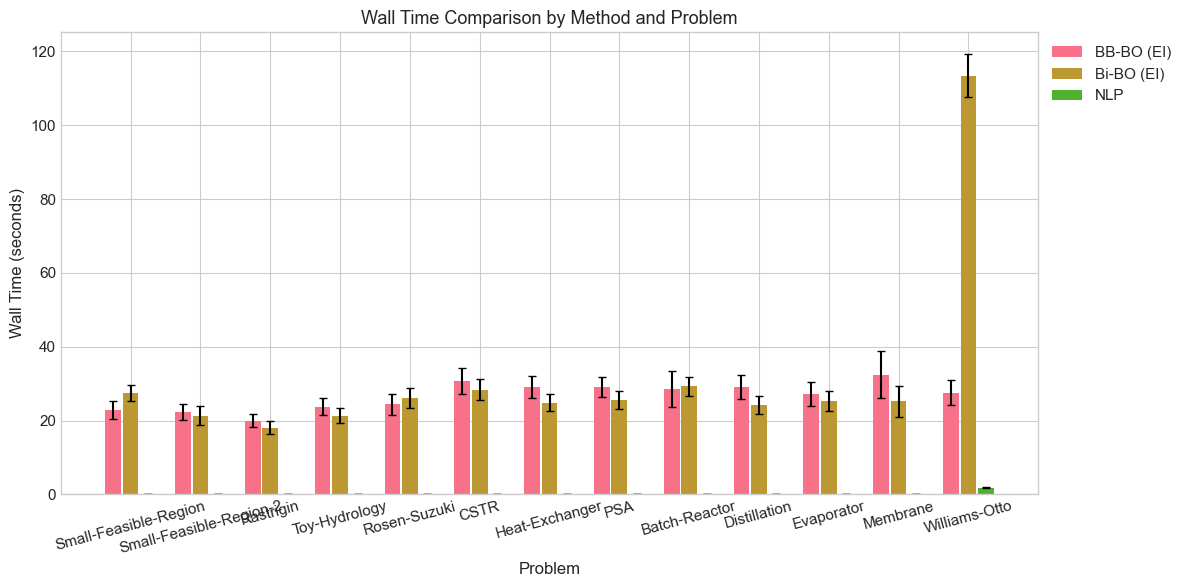

In [9]:
# Wall time aggregated by method and problem
df_time = df_valid.groupby(['method', 'problem']).agg({
    'wall_time': ['mean', 'std']
}).reset_index()
df_time.columns = ['method', 'problem', 'mean_time', 'std_time']

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

methods = df_time['method'].unique()
x = np.arange(len(problem_names))
width = 0.25
offsets = np.linspace(-width, width, len(methods))

for i, method in enumerate(methods):
    df_m = df_time[df_time['method'] == method].set_index('problem').reindex(problem_names)
    ax.bar(x + offsets[i], df_m['mean_time'], width=width*0.9, label=method,
           yerr=df_m['std_time'], capsize=3)

ax.set_xlabel('Problem')
ax.set_ylabel('Wall Time (seconds)')
ax.set_title('Wall Time Comparison by Method and Problem')
ax.set_xticks(x)
ax.set_xticklabels(problem_names, rotation=15)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('plots/wall_time_by_method.png', dpi=150, bbox_inches='tight')
plt.show()

IndexError: index 4 is out of bounds for axis 0 with size 4

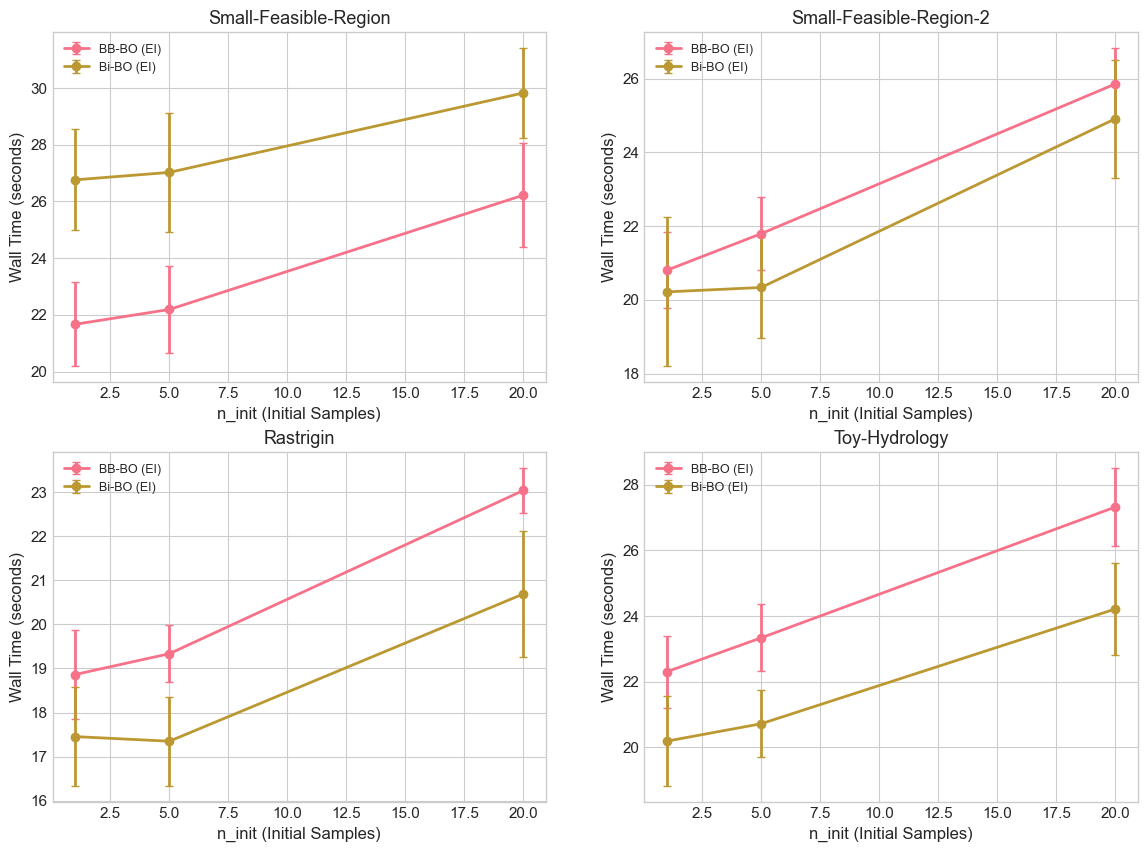

In [10]:
# Effect of n_init on wall time
df_time_ninit = df_bo.groupby(['n_init', 'method', 'problem']).agg({
    'wall_time': ['mean', 'std']
}).reset_index()
df_time_ninit.columns = ['n_init', 'method', 'problem', 'mean_time', 'std_time']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    df_prob = df_time_ninit[df_time_ninit['problem'] == prob]
    
    for method in df_prob['method'].unique():
        df_m = df_prob[df_prob['method'] == method].sort_values('n_init')
        ax.errorbar(df_m['n_init'], df_m['mean_time'], yerr=df_m['std_time'],
                   marker='o', label=method, capsize=3, linewidth=2)
    
    ax.set_xlabel('n_init (Initial Samples)')
    ax.set_ylabel('Wall Time (seconds)')
    ax.set_title(f'{prob}')
    ax.legend(loc='best', fontsize=9)

plt.suptitle('Effect of n_init on Wall Time', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/ninit_effect_walltime.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Black-Box Evaluations Comparison

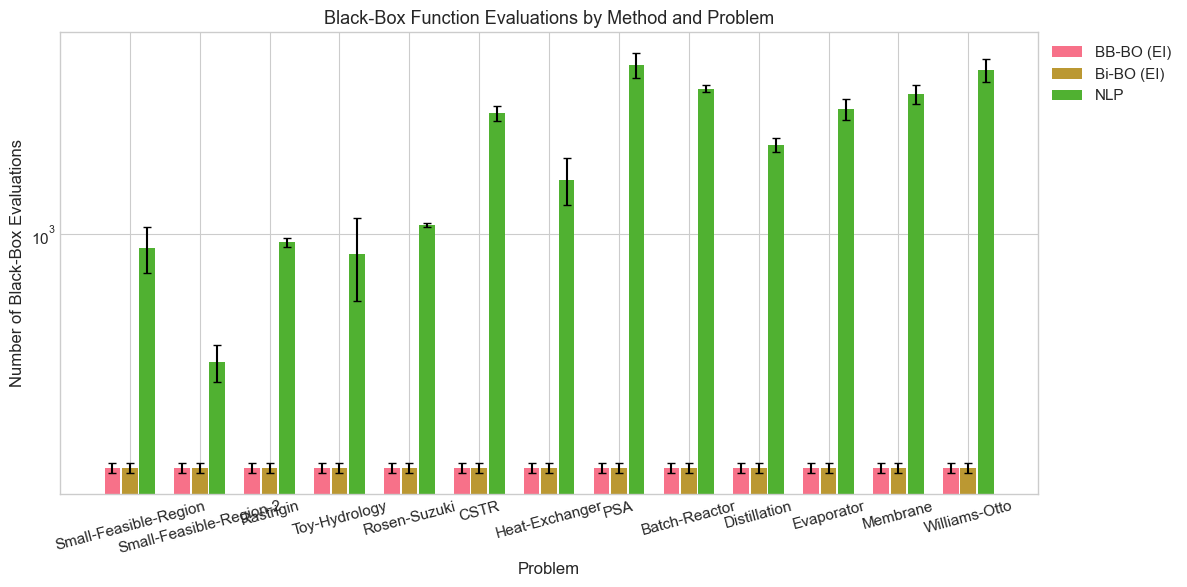

In [11]:
# Black-box evaluations aggregated by method and problem
df_evals = df_valid.groupby(['method', 'problem']).agg({
    'n_bb_evals': ['mean', 'std']
}).reset_index()
df_evals.columns = ['method', 'problem', 'mean_evals', 'std_evals']

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

methods = df_evals['method'].unique()
x = np.arange(len(problem_names))
width = 0.25
offsets = np.linspace(-width, width, len(methods))

for i, method in enumerate(methods):
    df_m = df_evals[df_evals['method'] == method].set_index('problem').reindex(problem_names)
    ax.bar(x + offsets[i], df_m['mean_evals'], width=width*0.9, label=method,
           yerr=df_m['std_evals'], capsize=3)

ax.set_xlabel('Problem')
ax.set_ylabel('Number of Black-Box Evaluations')
ax.set_title('Black-Box Function Evaluations by Method and Problem')
ax.set_xticks(x)
ax.set_xticklabels(problem_names, rotation=15)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('plots/bb_evals_by_method.png', dpi=150, bbox_inches='tight')
plt.show()

IndexError: index 4 is out of bounds for axis 0 with size 4

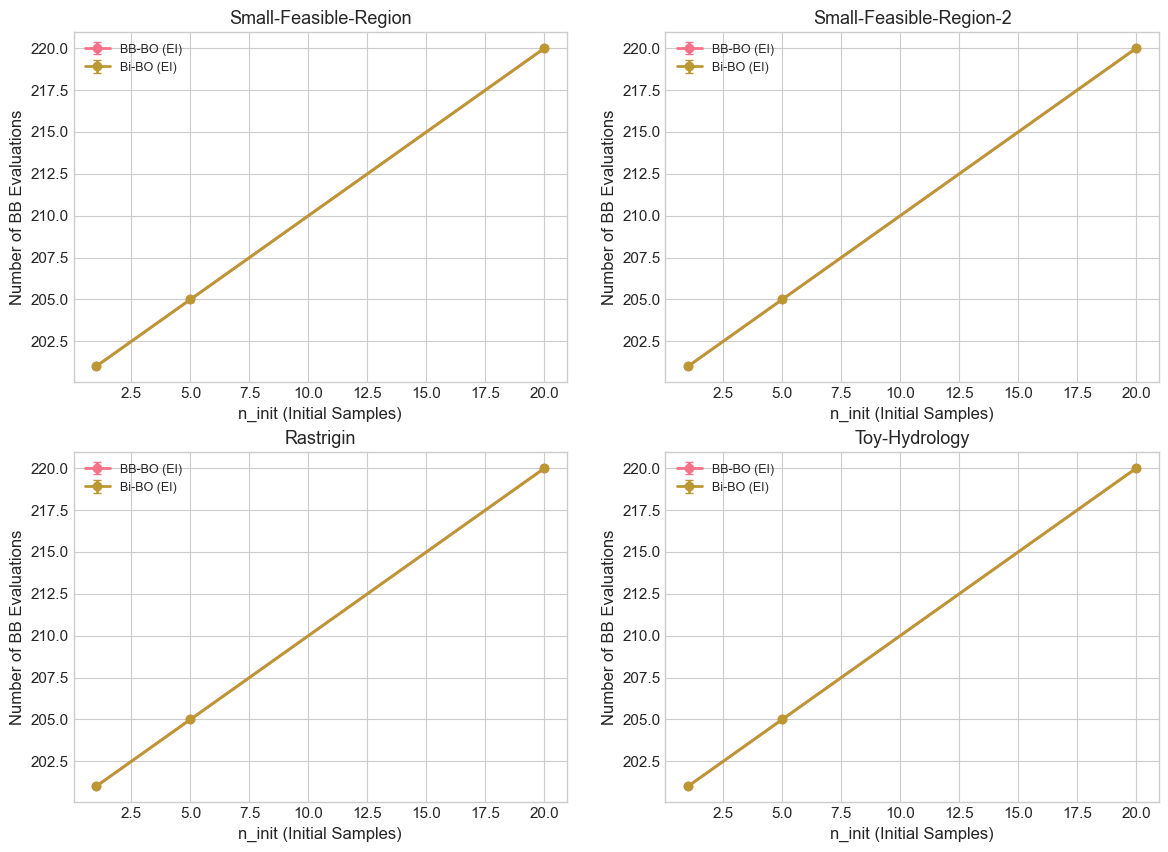

In [12]:
# Effect of n_init on black-box evaluations
df_evals_ninit = df_bo.groupby(['n_init', 'method', 'problem']).agg({
    'n_bb_evals': ['mean', 'std']
}).reset_index()
df_evals_ninit.columns = ['n_init', 'method', 'problem', 'mean_evals', 'std_evals']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    df_prob = df_evals_ninit[df_evals_ninit['problem'] == prob]
    
    for method in df_prob['method'].unique():
        df_m = df_prob[df_prob['method'] == method].sort_values('n_init')
        ax.errorbar(df_m['n_init'], df_m['mean_evals'], yerr=df_m['std_evals'],
                   marker='o', label=method, capsize=3, linewidth=2)
    
    ax.set_xlabel('n_init (Initial Samples)')
    ax.set_ylabel('Number of BB Evaluations')
    ax.set_title(f'{prob}')
    ax.legend(loc='best', fontsize=9)

plt.suptitle('Effect of n_init on Black-Box Evaluations', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/ninit_effect_bbevals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Regret vs. Black-Box Evaluations (Efficiency)

IndexError: index 4 is out of bounds for axis 0 with size 4

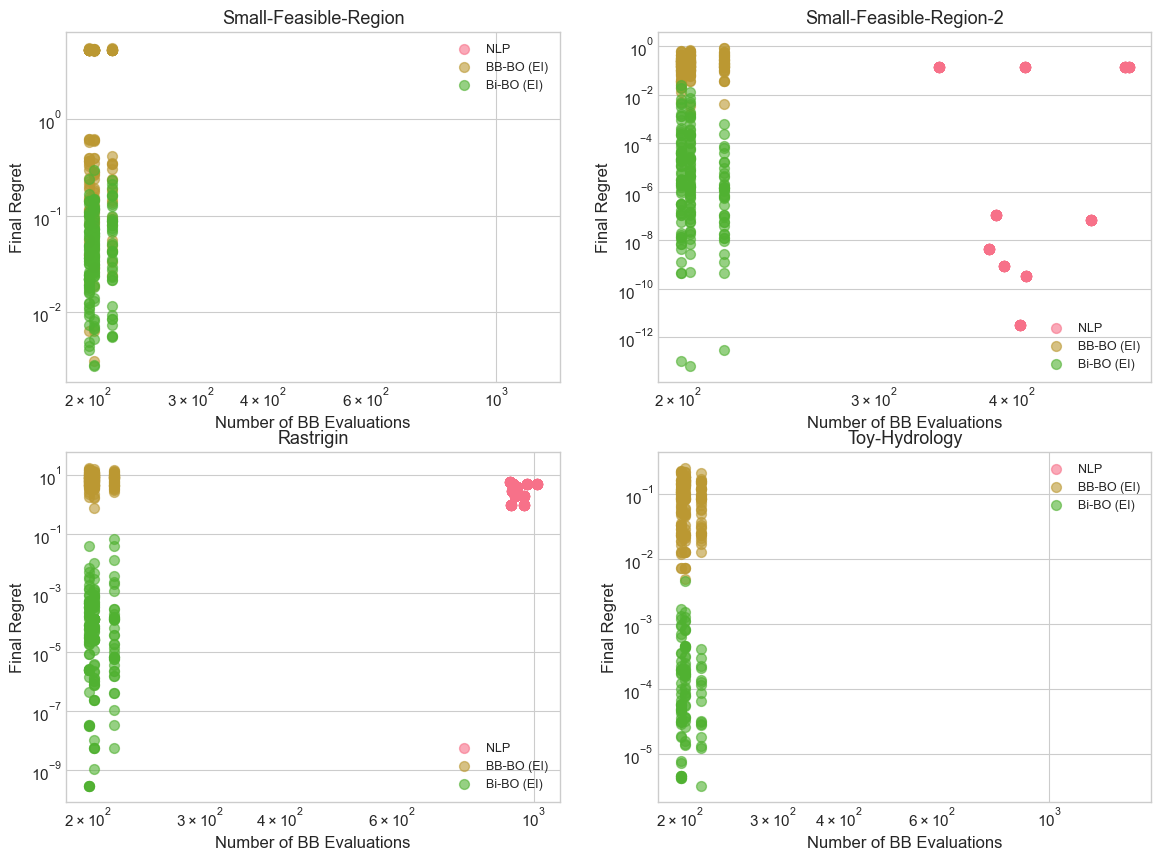

In [13]:
# Scatter: Regret vs BB Evaluations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    df_prob = df_valid[df_valid['problem'] == prob]
    
    for method in df_prob['method'].unique():
        df_m = df_prob[df_prob['method'] == method]
        ax.scatter(df_m['n_bb_evals'], df_m['final_regret'], 
                   label=method, alpha=0.6, s=50)
    
    ax.set_xlabel('Number of BB Evaluations')
    ax.set_ylabel('Final Regret')
    ax.set_title(f'{prob}')
    ax.legend(loc='best', fontsize=9)
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.suptitle('Efficiency: Final Regret vs. Black-Box Evaluations', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/efficiency_regret_vs_bbevals.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap: n_init vs xi Effect on Regret

In [ ]:
# Create heatmaps for each method and problem
methods_bo = [m for m in df_bo['method'].unique() if 'Bi-BO' in m]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    
    # Get Bi-BO data for this problem
    df_prob = df_bo[(df_bo['problem'] == prob) & (df_bo['method'].str.contains('Bi-BO'))]
    
    # Pivot to create heatmap data
    pivot = df_prob.groupby(['n_init', 'xi'])['final_regret'].mean().unstack()
    
    # Plot heatmap
    im = ax.imshow(np.log10(pivot.values), aspect='auto', cmap='RdYlGn_r')
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{x:.3f}' for x in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    
    ax.set_xlabel('xi')
    ax.set_ylabel('n_init')
    ax.set_title(f'{prob} - Bi-BO')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('log10(Final Regret)')

plt.suptitle('Bi-level BO: Effect of n_init and xi on Final Regret', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/heatmap_ninit_xi_bilevel.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Same for Black-box BO
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    
    # Get BB-BO data for this problem
    df_prob = df_bo[(df_bo['problem'] == prob) & (df_bo['method'].str.contains('BB-BO'))]
    
    # Pivot to create heatmap data
    pivot = df_prob.groupby(['n_init', 'xi'])['final_regret'].mean().unstack()
    
    # Plot heatmap
    im = ax.imshow(np.log10(pivot.values), aspect='auto', cmap='RdYlGn_r')
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{x:.3f}' for x in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    
    ax.set_xlabel('xi')
    ax.set_ylabel('n_init')
    ax.set_title(f'{prob} - BB-BO')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('log10(Final Regret)')

plt.suptitle('Black-box BO: Effect of n_init and xi on Final Regret', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/heatmap_ninit_xi_blackbox.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Regret Convergence Curves

IndexError: index 4 is out of bounds for axis 0 with size 4

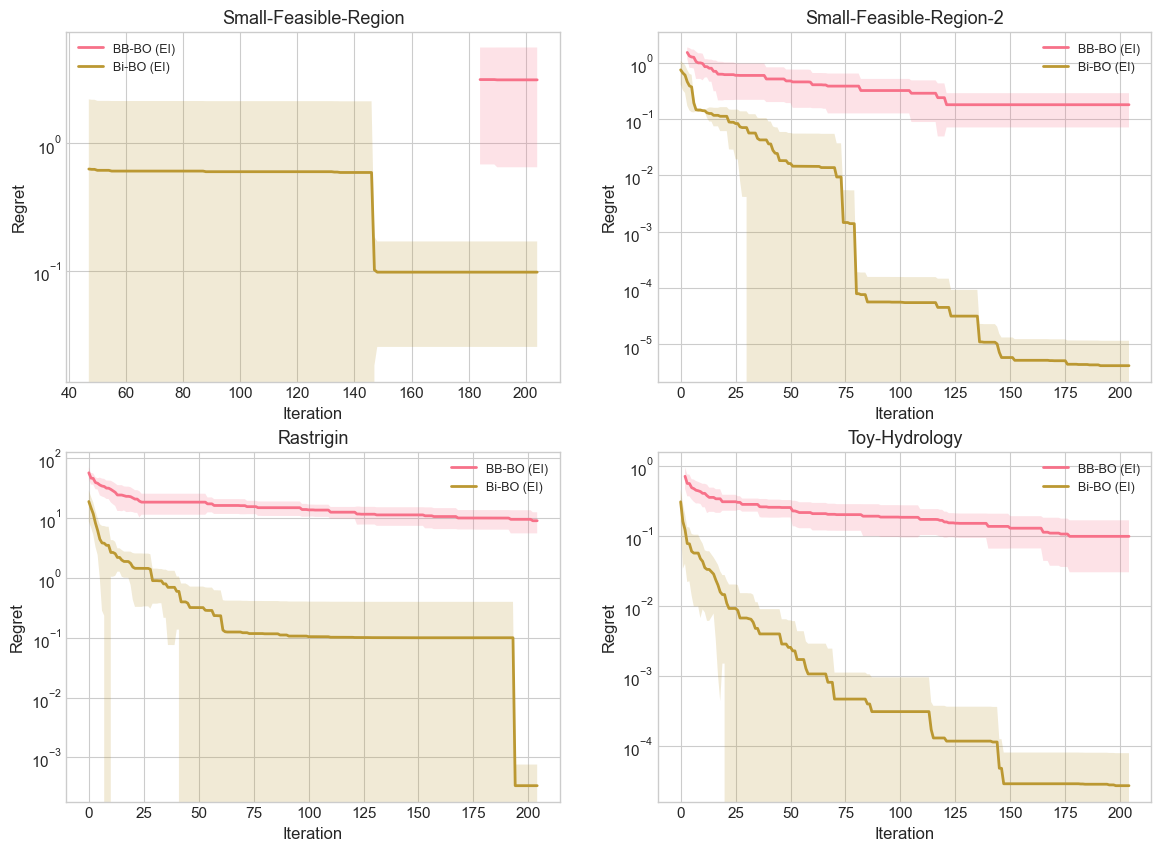

In [14]:
def extract_regret_curves(data_dict, n_init_filter=None, xi_filter=None):
    """Extract regret curves for plotting convergence."""
    curves = defaultdict(lambda: defaultdict(list))
    
    for (n_init, xi), data in data_dict.items():
        if n_init_filter is not None and n_init != n_init_filter:
            continue
        if xi_filter is not None and xi != xi_filter:
            continue
            
        results = data['results']
        
        for prob_name, prob_results in results.items():
            for acq in prob_results.get('acquisitions', ['ei']):
                # Black-box BO
                bb_key = f'blackbox_bo_{acq}'
                if bb_key in prob_results:
                    for regret_curve in prob_results[bb_key]['regrets']:
                        if not np.all(np.isinf(regret_curve)):
                            curves[prob_name][f'BB-BO ({acq.upper()})'].append(regret_curve)
                
                # Bi-level BO
                bi_key = f'bilevel_bo_{acq}'
                if bi_key in prob_results:
                    for regret_curve in prob_results[bi_key]['regrets']:
                        if not np.all(np.isinf(regret_curve)):
                            curves[prob_name][f'Bi-BO ({acq.upper()})'].append(regret_curve)
    
    return curves

# Plot convergence for a specific configuration
n_init_plot = 5
xi_plot = 0.01

curves = extract_regret_curves(all_data, n_init_filter=n_init_plot, xi_filter=xi_plot)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, prob in enumerate(problem_names):
    ax = axes[idx]
    
    if prob in curves:
        for method, method_curves in curves[prob].items():
            if len(method_curves) > 0:
                # Pad curves to same length
                max_len = max(len(c) for c in method_curves)
                padded = [np.pad(c, (0, max_len - len(c)), constant_values=c[-1]) 
                          for c in method_curves]
                arr = np.array(padded)
                
                mean = np.mean(arr, axis=0)
                std = np.std(arr, axis=0)
                
                x = np.arange(len(mean))
                ax.plot(x, mean, label=method, linewidth=2)
                ax.fill_between(x, mean - std, mean + std, alpha=0.2)
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Regret')
    ax.set_title(f'{prob}')
    ax.legend(loc='best', fontsize=9)
    ax.set_yscale('log')

plt.suptitle(f'Regret Convergence (n_init={n_init_plot}, xi={xi_plot})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'plots/convergence_ninit{n_init_plot}_xi{xi_plot}.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Statistics Table

In [15]:
# Create comprehensive summary table
summary_rows = []

for (n_init, xi), data in sorted(all_data.items()):
    results = data['results']
    
    for prob_name, prob_results in results.items():
        # NLP baseline
        nlp_regrets = prob_results['blackbox_nlp']['final_regrets']
        nlp_times = prob_results['blackbox_nlp']['wall_times']
        nlp_evals = prob_results['blackbox_nlp']['n_fbb_evals']
        
        summary_rows.append({
            'n_init': n_init,
            'xi': xi,
            'problem': prob_name,
            'method': 'NLP',
            'mean_regret': np.mean(nlp_regrets),
            'std_regret': np.std(nlp_regrets),
            'mean_time': np.mean(nlp_times),
            'mean_bb_evals': np.mean(nlp_evals)
        })
        
        for acq in prob_results.get('acquisitions', ['ei']):
            # BB-BO
            bb_key = f'blackbox_bo_{acq}'
            if bb_key in prob_results:
                bb_data = prob_results[bb_key]
                final_regrets = [r[-1] for r in bb_data['regrets'] if not np.isinf(r[-1])]
                if final_regrets:
                    summary_rows.append({
                        'n_init': n_init,
                        'xi': xi,
                        'problem': prob_name,
                        'method': f'BB-BO ({acq.upper()})',
                        'mean_regret': np.mean(final_regrets),
                        'std_regret': np.std(final_regrets),
                        'mean_time': np.mean(bb_data['wall_times']),
                        'mean_bb_evals': np.mean(bb_data['n_fbb_evals'])
                    })
            
            # Bi-BO
            bi_key = f'bilevel_bo_{acq}'
            if bi_key in prob_results:
                bi_data = prob_results[bi_key]
                final_regrets = [r[-1] for r in bi_data['regrets'] if not np.isinf(r[-1])]
                if final_regrets:
                    summary_rows.append({
                        'n_init': n_init,
                        'xi': xi,
                        'problem': prob_name,
                        'method': f'Bi-BO ({acq.upper()})',
                        'mean_regret': np.mean(final_regrets),
                        'std_regret': np.std(final_regrets),
                        'mean_time': np.mean(bi_data['wall_times']),
                        'mean_bb_evals': np.mean(bi_data['n_fbb_evals'])
                    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,n_init,xi,problem,method,mean_regret,std_regret,mean_time,mean_bb_evals
0,1,0.001,Small-Feasible-Region,NLP,-0.202589,1.012937e-01,0.029679,910.0
1,1,0.001,Small-Feasible-Region,BB-BO (EI),2.182184,2.465815e+00,23.086793,201.0
2,1,0.001,Small-Feasible-Region,Bi-BO (EI),0.041678,3.260848e-02,27.557003,201.0
3,1,0.001,Small-Feasible-Region-2,NLP,0.054613,6.688701e-02,0.023977,422.2
4,1,0.001,Small-Feasible-Region-2,BB-BO (EI),0.250593,2.055647e-01,21.169031,201.0
...,...,...,...,...,...,...,...,...
697,20,0.100,Membrane,BB-BO (EI),25.589417,1.011108e+01,38.888440,220.0
698,20,0.100,Membrane,Bi-BO (EI),-0.000222,1.332972e-04,29.463264,220.0
699,20,0.100,Williams-Otto,NLP,-0.009762,1.116924e-07,1.771112,3031.1
700,20,0.100,Williams-Otto,BB-BO (EI),3.171448,1.550286e+00,32.044657,220.0


In [16]:
# Best configuration per problem and method
best_configs = df_summary.loc[df_summary.groupby(['problem', 'method'])['mean_regret'].idxmin()]
print("Best (n_init, xi) configuration for each problem and method:")
print("=" * 80)
best_configs[['problem', 'method', 'n_init', 'xi', 'mean_regret', 'std_regret']].sort_values(['problem', 'mean_regret'])

Best (n_init, xi) configuration for each problem and method:


,problem,method,n_init,xi,mean_regret,std_regret
24,Batch-Reactor,NLP,1,0.001,-3.180664e-04,3.464293e-08
260,Batch-Reactor,Bi-BO (EI),1,1.000,2.785762e-02,2.847552e-02
103,Batch-Reactor,BB-BO (EI),1,0.050,9.448618e-01,3.541356e-01
15,CSTR,NLP,1,0.001,-4.615901e-05,2.351216e-10
290,CSTR,Bi-BO (EI),5,0.001,5.162539e-03,3.641724e-03
211,CSTR,BB-BO (EI),1,0.500,2.770554e+00,1.307510e+00
27,Distillation,NLP,1,0.001,-1.671065e+00,1.652598e+00
575,Distillation,Bi-BO (EI),20,0.001,-8.159072e-01,3.980283e-02
301,Distillation,BB-BO (EI),5,0.001,5.555413e+03,2.747522e+03
30,Evaporator,NLP,1,0.001,3.316515e-06,1.440508e-09


## 11. Bi-level vs Black-box BO Comparison

In [17]:
# Compare Bi-BO vs BB-BO directly
df_comparison = df_summary[df_summary['method'].isin(['BB-BO (EI)', 'Bi-BO (EI)'])].copy()

# Pivot to compare
pivot = df_comparison.pivot_table(
    index=['n_init', 'xi', 'problem'],
    columns='method',
    values='mean_regret'
).reset_index()

pivot['improvement_ratio'] = pivot['BB-BO (EI)'] / pivot['Bi-BO (EI)']
pivot['bi_better'] = pivot['Bi-BO (EI)'] < pivot['BB-BO (EI)']

print("Comparison: Bi-BO (EI) vs BB-BO (EI)")
print("=" * 80)
print(f"Cases where Bi-BO is better: {pivot['bi_better'].sum()} / {len(pivot)}")
print(f"\nMean improvement ratio (BB/Bi): {pivot['improvement_ratio'].mean():.2f}x")
print(f"Median improvement ratio (BB/Bi): {pivot['improvement_ratio'].median():.2f}x")

pivot.sort_values('improvement_ratio', ascending=False).head(10)

Comparison: Bi-BO (EI) vs BB-BO (EI)
Cases where Bi-BO is better: 234 / 234

Mean improvement ratio (BB/Bi): 60919.56x
Median improvement ratio (BB/Bi): 39.52x


method,n_init,xi,problem,BB-BO (EI),Bi-BO (EI),improvement_ratio,bi_better
192,20,0.001,Small-Feasible-Region-2,0.301253,3.250781e-08,9.267095e+06,True
225,20,0.100,Heat-Exchanger,118.657045,1.857953e-04,6.386441e+05,True
199,20,0.010,Heat-Exchanger,115.479564,1.848062e-04,6.248686e+05,True
212,20,0.050,Heat-Exchanger,115.479564,1.851424e-04,6.237339e+05,True
186,20,0.001,Heat-Exchanger,107.497340,1.847166e-04,5.819581e+05,True
205,20,0.010,Small-Feasible-Region-2,0.293917,7.991471e-07,3.677885e+05,True
56,1,0.200,Heat-Exchanger,67.519581,1.871202e-04,3.608354e+05,True
95,5,0.001,Heat-Exchanger,61.204512,1.849139e-04,3.309893e+05,True
160,5,0.500,Heat-Exchanger,61.339869,1.891263e-04,3.243328e+05,True
121,5,0.050,Heat-Exchanger,59.925027,1.851891e-04,3.235883e+05,True


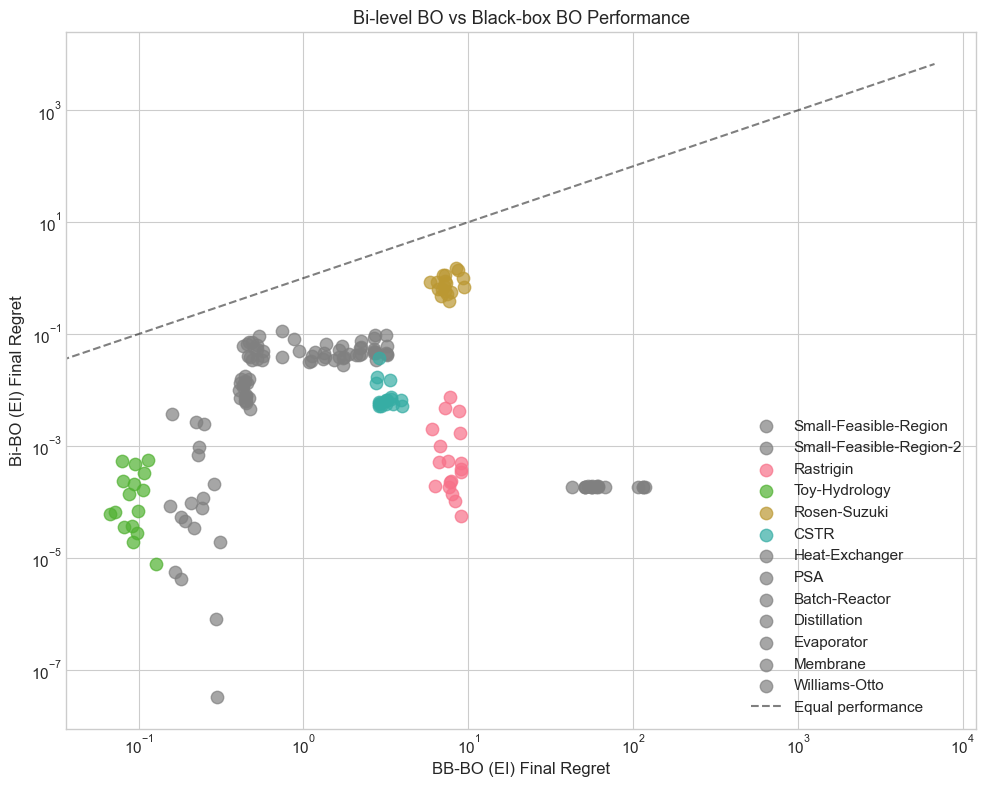

In [18]:
# Scatter plot: Bi-BO vs BB-BO regret
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Rastrigin': 'C0', 'Rosen-Suzuki': 'C1', 'Toy-Hydrology': 'C2', 'CSTR': 'C3'}

for prob in problem_names:
    df_p = pivot[pivot['problem'] == prob]
    ax.scatter(df_p['BB-BO (EI)'], df_p['Bi-BO (EI)'], 
               label=prob, color=colors.get(prob, 'gray'), s=80, alpha=0.7)

# Add diagonal line (y=x)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), 
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Equal performance')

ax.set_xlabel('BB-BO (EI) Final Regret')
ax.set_ylabel('Bi-BO (EI) Final Regret')
ax.set_title('Bi-level BO vs Black-box BO Performance')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('plots/bilevel_vs_blackbox_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Key Findings Summary

In [19]:
print("="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

# Best overall configurations
print("\n1. BEST CONFIGURATIONS BY PROBLEM (Bi-BO)")
print("-"*80)
bi_bo_summary = df_summary[df_summary['method'] == 'Bi-BO (EI)'].copy()
for prob in problem_names:
    best = bi_bo_summary[bi_bo_summary['problem'] == prob].nsmallest(1, 'mean_regret')
    if not best.empty:
        row = best.iloc[0]
        print(f"  {prob}: n_init={int(row['n_init'])}, xi={row['xi']:.3f} -> regret={row['mean_regret']:.6f}")

# Overall performance comparison
print("\n2. OVERALL METHOD COMPARISON (averaged over all configs)")
print("-"*80)
method_summary = df_summary.groupby('method').agg({
    'mean_regret': 'mean',
    'mean_time': 'mean',
    'mean_bb_evals': 'mean'
}).round(4)
print(method_summary)

# n_init effect
print("\n3. EFFECT OF n_init (averaged over xi and problems)")
print("-"*80)
ninit_effect = df_summary[df_summary['method'] == 'Bi-BO (EI)'].groupby('n_init')['mean_regret'].mean()
print(ninit_effect)

# xi effect
print("\n4. EFFECT OF xi (averaged over n_init and problems)")
print("-"*80)
xi_effect = df_summary[df_summary['method'] == 'Bi-BO (EI)'].groupby('xi')['mean_regret'].mean()
print(xi_effect)

KEY FINDINGS SUMMARY

1. BEST CONFIGURATIONS BY PROBLEM (Bi-BO)
--------------------------------------------------------------------------------
  Small-Feasible-Region: n_init=1, xi=0.200 -> regret=0.034510
  Small-Feasible-Region-2: n_init=20, xi=0.001 -> regret=0.000000
  Rastrigin: n_init=20, xi=0.001 -> regret=0.000056
  Toy-Hydrology: n_init=20, xi=0.001 -> regret=-0.000011
  Rosen-Suzuki: n_init=1, xi=0.500 -> regret=0.390928
  CSTR: n_init=5, xi=0.001 -> regret=0.005163
  Heat-Exchanger: n_init=20, xi=0.001 -> regret=0.000185
  PSA: n_init=5, xi=0.200 -> regret=0.004602
  Batch-Reactor: n_init=1, xi=1.000 -> regret=0.027858
  Distillation: n_init=20, xi=0.001 -> regret=-0.815907
  Evaporator: n_init=1, xi=0.100 -> regret=0.034520
  Membrane: n_init=1, xi=0.500 -> regret=-0.000314
  Williams-Otto: n_init=20, xi=0.001 -> regret=-0.009745

2. OVERALL METHOD COMPARISON (averaged over all configs)
--------------------------------------------------------------------------------
     

In [ ]:
# Save summary to CSV
df_summary.to_csv('plots/experiment_summary.csv', index=False)
print("Summary saved to plots/experiment_summary.csv")